In [5]:
#Yishu Yang N-number: 11323324 for random number seeds

In [6]:
#GLOBAL PREPROCESSING
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_SEED = 11323324
np.random.seed(RANDOM_SEED)

nums = pd.read_csv('rmpCapstoneNum.csv', header=None)
tags = pd.read_csv('rmpCapstoneTags.csv', header=None)
qual = pd.read_csv('rmpCapstoneQual.csv', header=None) # The third file


nums.columns = ['Rating', 'Difficulty', 'NumRatings', 'TakeAgain', 'Online', 'Pepper', 'Female', 'Male']
tag_cols = [f'Tag_{i}' for i in range(20)]
tags.columns = tag_cols
qual.columns = ['Major', 'University', 'State']

# Combine into one Master DataFrame
df_full = pd.concat([nums, tags, qual], axis=1)

df_modeling = df_full.dropna(subset=['Rating']).copy()

# Normalize Tags (divide raw counts by NumRatings)
df_modeling = df_modeling[df_modeling['NumRatings'] > 0]
for col in tag_cols:
    df_modeling[col] = df_modeling[col] / df_modeling['NumRatings']


scaler = StandardScaler()
num_preds = ['Difficulty', 'NumRatings', 'TakeAgain', 'Online', 'Pepper', 'Male']


for col in num_preds:
    df_modeling[col] = df_modeling[col].fillna(df_modeling[col].median())
# We use NumRatings as weights to prioritize professors with established reputations
weights = df_modeling['NumRatings']


scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_modeling[num_preds])

X_tags_scaled = scaler.fit_transform(df_modeling[tag_cols])


In [7]:
#Q1
import statsmodels.formula.api as smf
from scipy import stats

ALPHA = 0.005

# Use your already-preprocessed dataframe
dfq1 = df_modeling.copy()
dfq1["MaleInd"] = dfq1["Male"].astype(int)  # 1=male, 0=female

# Weighted t-test via WLS
model = smf.wls(
    "Rating ~ MaleInd",
    data=dfq1,
    weights=dfq1["NumRatings"]
).fit(cov_type="HC3")

beta = model.params["MaleInd"]
tval = model.tvalues["MaleInd"]
df_resid = model.df_resid

# One-sided p-value: H1 = pro-male bias (beta > 0)
p_one_sided = stats.t.sf(tval, df_resid)

print(f"Male coefficient: {beta:.4f}")
print(f"One-sided p-value: {p_one_sided:.4g}")
print(f"Significant at alpha={ALPHA}? {p_one_sided < ALPHA}")

Male coefficient: -0.0014
One-sided p-value: 0.5447
Significant at alpha=0.005? False


In [8]:
#Q2
from scipy.stats import levene
import numpy as np

ALPHA = 0.005

dfq2 = df_modeling.copy()

male_ratings = dfq2.loc[dfq2["Male"] == 1, "Rating"].to_numpy()
female_ratings = dfq2.loc[dfq2["Female"] == 1, "Rating"].to_numpy()

# Levene's test (median-centered, robust)
stat, pval = levene(male_ratings, female_ratings, center="median")

print(f"Std (male): {np.std(male_ratings, ddof=1):.4f}")
print(f"Std (female): {np.std(female_ratings, ddof=1):.4f}")
print(f"Levene p-value: {pval:.4g}")
print(f"Significant at alpha={ALPHA}? {pval < ALPHA}")


Std (male): 1.1425
Std (female): 1.0881
Levene p-value: 1.399e-18
Significant at alpha=0.005? True


In [9]:
# Q3: Likely size of Gender Bias (Rating and Spread)
import numpy as np

# Data Prep
male_ratings = df_modeling[df_modeling['Male'] == 1]['Rating']
female_ratings = df_modeling[df_modeling['Female'] == 1]['Rating']

# 1. Size of Average Rating Bias (Mean Difference)
m_mean, f_mean = male_ratings.mean(), female_ratings.mean()
diff_mean = m_mean - f_mean
n_m, n_f = len(male_ratings), len(female_ratings)
var_m, var_f = male_ratings.var(), female_ratings.var()

# Welch's SE for Difference in Means
se_mean_diff = np.sqrt(var_m/n_m + var_f/n_f)
ci_mean = [diff_mean - 1.96 * se_mean_diff, diff_mean + 1.96 * se_mean_diff]

# 2. Size of Spread Bias (Standard Deviation Difference)
m_std, f_std = male_ratings.std(), female_ratings.std()
diff_std = m_std - f_std

# SE for Difference in Standard Deviations (Large Sample Approximation)
se_std_diff = np.sqrt((m_std**2 / (2 * n_m)) + (f_std**2 / (2 * n_f)))
ci_std = [diff_std - 1.96 * se_std_diff, diff_std + 1.96 * se_std_diff]

print("--- Question 3: Effect Sizes and 95% Confidence Intervals ---")
print(f"Bias in Average Rating: {diff_mean:.4f}")
print(f"95% CI for Rating Bias: [{ci_mean[0]:.4f}, {ci_mean[1]:.4f}]")
print(f"\nBias in Rating Spread (Std Dev): {diff_std:.4f}")
print(f"95% CI for Spread Bias: [{ci_std[0]:.4f}, {ci_std[1]:.4f}]")

--- Question 3: Effect Sizes and 95% Confidence Intervals ---
Bias in Average Rating: -0.0612
95% CI for Rating Bias: [-0.0797, -0.0428]

Bias in Rating Spread (Std Dev): 0.0544
95% CI for Spread Bias: [0.0413, 0.0674]


In [10]:
# Q4
tag_diffs = []

for tag in tag_cols:
    m_tag = df_modeling[df_modeling['Male'] == 1][tag]
    f_tag = df_modeling[df_modeling['Female'] == 1][tag]

    t_stat, p_val = stats.ttest_ind(m_tag, f_tag, nan_policy='omit')

    tag_diffs.append({
        'Tag': tag,
        'Male_Mean': m_tag.mean(),
        'Female_Mean': f_tag.mean(),
        'p-value': p_val,
        'Significant': p_val < 0.005
    })

df_q4 = pd.DataFrame(tag_diffs)

print("--- Question 4: Normalized Tag Differences ---")
sig_tags = df_q4[df_q4['Significant'] == True]
print(f"Found {len(sig_tags)} tags with significant gender differences at alpha 0.005.")

print("\nTop 5 Tags with most significant differences:")
print(df_q4.sort_values('p-value').head(5)[['Tag', 'Male_Mean', 'Female_Mean', 'p-value']])

--- Question 4: Normalized Tag Differences ---
Found 19 tags with significant gender differences at alpha 0.005.

Top 5 Tags with most significant differences:
       Tag  Male_Mean  Female_Mean        p-value
12  Tag_12   0.075923     0.133146  1.754956e-200
15  Tag_15   0.075509     0.101519   4.338413e-56
16  Tag_16   0.204903     0.172935   3.110385e-43
2    Tag_2   0.142148     0.169973   3.506021e-37
19  Tag_19   0.073444     0.093545   3.391015e-33


In [11]:
#Q5
from scipy import stats
import numpy as np

male_diff = df_modeling[df_modeling['Male'] == 1]
female_diff = df_modeling[df_modeling['Female'] == 1]


mean_m = np.average(male_diff['Difficulty'], weights=male_diff['NumRatings'])
mean_f = np.average(female_diff['Difficulty'], weights=female_diff['NumRatings'])
diff = mean_m - mean_f

t_stat5, p_val5 = stats.ttest_ind(male_diff['Difficulty'], female_diff['Difficulty'],
                                  equal_var=False, nan_policy='omit')

n_m, n_f = len(male_diff), len(female_diff)
var_m, var_f = male_diff['Difficulty'].var(), female_diff['Difficulty'].var()
sed = np.sqrt(var_m/n_m + var_f/n_f)
ci_low, ci_high = diff - 1.96 * sed, diff + 1.96 * sed

print("--- Question 5: Average Difficulty by Gender ---")
print(f"Weighted Mean (Male):   {mean_m:.3f}")
print(f"Weighted Mean (Female): {mean_f:.3f}")
print(f"Difference in Means:    {diff:.3f}")
print(f"95% CI for Difference:  [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Welch's T-stat: {t_stat5:.4f}, p-value: {p_val5:.4e}")

# Decision at alpha=0.005
if p_val5 < 0.005:
    print("\nConclusion: Significant gender difference in average difficulty.")
else:
    print("\nConclusion: No significant gender difference in average difficulty.")

--- Question 5: Average Difficulty by Gender ---
Weighted Mean (Male):   2.889
Weighted Mean (Female): 2.901
Difference in Means:    -0.012
95% CI for Difference:  [-0.029, 0.004]
Welch's T-stat: 0.5690, p-value: 5.6937e-01

Conclusion: No significant gender difference in average difficulty.


In [12]:
#Q6
from scipy import stats

diff_male = df_modeling.loc[df_modeling['Male'] == 1, 'Difficulty']
diff_female = df_modeling.loc[df_modeling['Female'] == 1, 'Difficulty']


mean_m, mean_f = diff_male.mean(), diff_female.mean()
mean_diff = mean_f - mean_m  # Female - Male


se_diff = np.sqrt(diff_female.var()/len(diff_female) + diff_male.var()/len(diff_male))

v_f, v_m = diff_female.var(), diff_male.var()
n_f, n_m = len(diff_female), len(diff_male)
df_welch = (v_f/n_f + v_m/n_m)**2 / ((v_f/n_f)**2/(n_f-1) + (v_m/n_m)**2/(n_m-1))


t_crit = stats.t.ppf(0.975, df_welch)
ci_low, ci_high = mean_diff - t_crit * se_diff, mean_diff + t_crit * se_diff


sd_pooled = np.sqrt(((n_m - 1)*v_m + (n_f - 1)*v_f) / (n_m + n_f - 2))
cohens_d = mean_diff / sd_pooled

print("--- Question 6: Effect Size Results ---")
print(f"Mean Difference (F - M):  {mean_diff:.4f}")
print(f"95% CI for Difference:    [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Cohen's d:                {cohens_d:.4f}")

# Interpretation of Cohen's d
if abs(cohens_d) < 0.2:
    interpretation = "Negligible/Small"
elif abs(cohens_d) < 0.5:
    interpretation = "Medium"
else:
    interpretation = "Large"
print(f"Effect Size Interpretation: {interpretation}")

--- Question 6: Effect Size Results ---
Mean Difference (F - M):  -0.0048
95% CI for Difference:    [-0.0211, 0.0116]
Cohen's d:                -0.0048
Effect Size Interpretation: Negligible/Small


In [13]:
#Q7
X_train7, X_test7, y_train7, y_test7, w_train7, w_test7 = train_test_split(
    X_num_scaled, df_modeling['Rating'], weights, test_size=0.2, random_state=RANDOM_SEED
)

model7 = LinearRegression()
model7.fit(X_train7, y_train7, sample_weight=w_train7)

y_pred7 = model7.predict(X_test7)
print("--- Question 7 Results ---")
print(f"R²: {r2_score(y_test7, y_pred7, sample_weight=w_test7):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test7, y_pred7, sample_weight=w_test7)):.4f}")

coeffs7 = pd.Series(model7.coef_, index=num_preds)
print(f"Most Predictive Factor: {coeffs7.abs().idxmax()} ({coeffs7[coeffs7.abs().idxmax()]:.4f})")

--- Question 7 Results ---
R²: 0.5349
RMSE: 0.6701
Most Predictive Factor: Difficulty (-0.5056)


In [14]:
#Q8
X_train8, X_test8, y_train8, y_test8, w_train8, w_test8 = train_test_split(
    X_tags_scaled, df_modeling['Rating'], weights, test_size=0.2, random_state=RANDOM_SEED
)

model8 = LinearRegression()
model8.fit(X_train8, y_train8, sample_weight=w_train8)

y_pred8 = model8.predict(X_test8)
print("--- Question 8 Results ---")
print(f"R²: {r2_score(y_test8, y_pred8, sample_weight=w_test8):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test8, y_pred8, sample_weight=w_test8)):.4f}")

coeffs8 = pd.Series(model8.coef_, index=tag_cols)
print(f"Most Predictive Tag: {coeffs8.abs().idxmax()} ({coeffs8[coeffs8.abs().idxmax()]:.4f})")

--- Question 8 Results ---
R²: 0.6637
RMSE: 0.5698
Most Predictive Tag: Tag_0 (-0.3016)


In [15]:
#Q9
X_train9, X_test9, y_train9, y_test9, w_train9, w_test9 = train_test_split(
    X_tags_scaled, df_modeling['Difficulty'], weights, test_size=0.2, random_state=RANDOM_SEED
)


model9 = LinearRegression()
model9.fit(X_train9, y_train9, sample_weight=w_train9)

y_pred9 = model9.predict(X_test9)
print("--- Question 9 Results ---")
print(f"R²: {r2_score(y_test9, y_pred9, sample_weight=w_test9):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test9, y_pred9, sample_weight=w_test9)):.4f}")

coeffs9 = pd.Series(model9.coef_, index=tag_cols)
print(f"Most Predictive Tag: {coeffs9.abs().idxmax()} ({coeffs9[coeffs9.abs().idxmax()]:.4f})")

--- Question 9 Results ---
R²: 0.4765
RMSE: 0.6117
Most Predictive Tag: Tag_0 (0.4504)


In [16]:
#Q10
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


df_modeling['HasPepper'] = (df_modeling['Pepper'] > 0).astype(int)
y10 = df_modeling['HasPepper']

numeric_to_scale = ['Rating', 'Difficulty', 'TakeAgain', 'Online', 'Male']
scaler_q10 = StandardScaler()
X_num_q10 = scaler_q10.fit_transform(df_modeling[numeric_to_scale])

X10 = np.hstack([X_tags_scaled, X_num_q10])

X_train10, X_test10, y_train10, y_test10, w_train10, w_test10 = train_test_split(
    X10, y10, weights, test_size=0.2, random_state=RANDOM_SEED, stratify=y10
)
model10 = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED)
model10.fit(X_train10, y_train10, sample_weight=w_train10)

y_pred10 = model10.predict(X_test10)
y_proba10 = model10.predict_proba(X_test10)[:, 1]

print("--- Question 10: Classification (Has Pepper) ---")
print(f"AUROC Score: {roc_auc_score(y_test10, y_proba10):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test10, y_pred10))

feature_names = tag_cols + numeric_to_scale
coeffs10 = pd.Series(model10.coef_[0], index=feature_names)
print("\nTop 5 Positive Predictors (Likely to have a Pepper):")
print(coeffs10.sort_values(ascending=False).head(5))

--- Question 10: Classification (Has Pepper) ---
AUROC Score: 0.6778

Confusion Matrix:
[[5055 6761]
 [ 422 1763]]

Top 5 Positive Predictors (Likely to have a Pepper):
Tag_11       0.380765
Tag_1        0.206540
Tag_3        0.170395
TakeAgain    0.151817
Tag_4        0.134816
dtype: float64


In [17]:
#Extra Credit
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import plotly.express as px

# Regions
east_coast_states = ['ME', 'NH', 'MA', 'RI', 'CT', 'NY', 'NJ', 'DE', 'MD', 'VA', 'NC', 'SC', 'GA', 'FL']
west_coast_states = ['WA', 'OR', 'CA']

def get_region(state):
    if state in east_coast_states: return 'East Coast'
    if state in west_coast_states: return 'West Coast'
    return 'Inland'

df_modeling['Region'] = df_modeling['State'].apply(get_region)

# ANOVA
model_ec = ols('Rating ~ Region', data=df_modeling).fit()
anova_table = sm.stats.anova_lm(model_ec, typ=2)


eta_sq = anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

regional_stats = []
for region in ['West Coast', 'East Coast', 'Inland']:
    subset = df_modeling[df_modeling['Region'] == region]
    w_mean = np.average(subset['Rating'], weights=subset['NumRatings'])

    # Standard Error of the mean (weighted)
    se = subset['Rating'].std() / np.sqrt(len(subset))
    ci_low, ci_high = w_mean - 1.96 * se, w_mean + 1.96 * se

    regional_stats.append({
        'Region': region,
        'Count': len(subset),
        'Weighted Mean': w_mean,
        '95% CI': f"[{ci_low:.3f}, {ci_high:.3f}]"
    })

print("--- Extra Credit: Regional Stats ---")
print(pd.DataFrame(regional_stats))
print(f"\nEffect Size (Eta-Squared): {eta_sq:.5f}")


state_data = df_modeling.groupby('State')['Rating'].mean().reset_index()

fig = px.choropleth(
    state_data,
    locations='State',
    locationmode="USA-states",
    color='Rating',
    scope="usa",
    # Zooming range to [3.5, 4.2] to make the 0.2 difference pop visually
    range_color=[3.5, 4.2],
    color_continuous_scale="RdYlGn",
    title="Heatmap: Small Variations in Avg Rating (Scale: 3.5 - 4.2)"
)
fig.show()

/tmp/ipython-input-772771976.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])


--- Extra Credit: Regional Stats ---
       Region  Count  Weighted Mean          95% CI
0  West Coast  10352       3.963886  [3.943, 3.984]
1  East Coast  22892       3.879439  [3.865, 3.894]
2      Inland  36760       3.834136  [3.822, 3.846]

Effect Size (Eta-Squared): 0.00107


## Data Visualisation



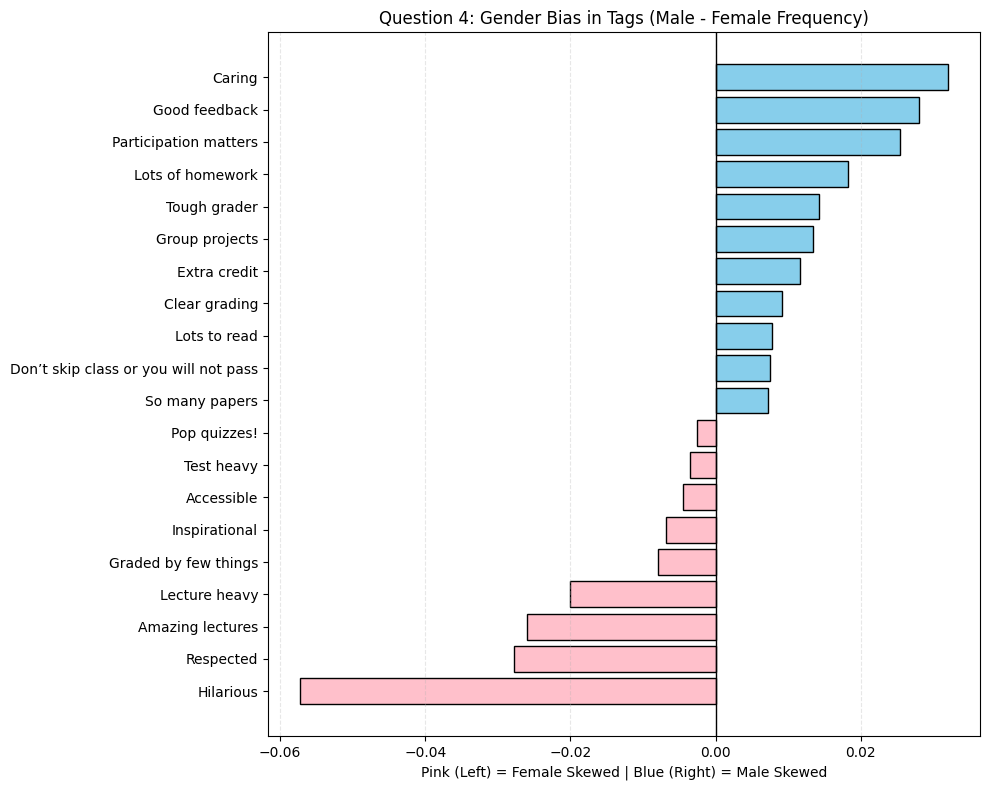

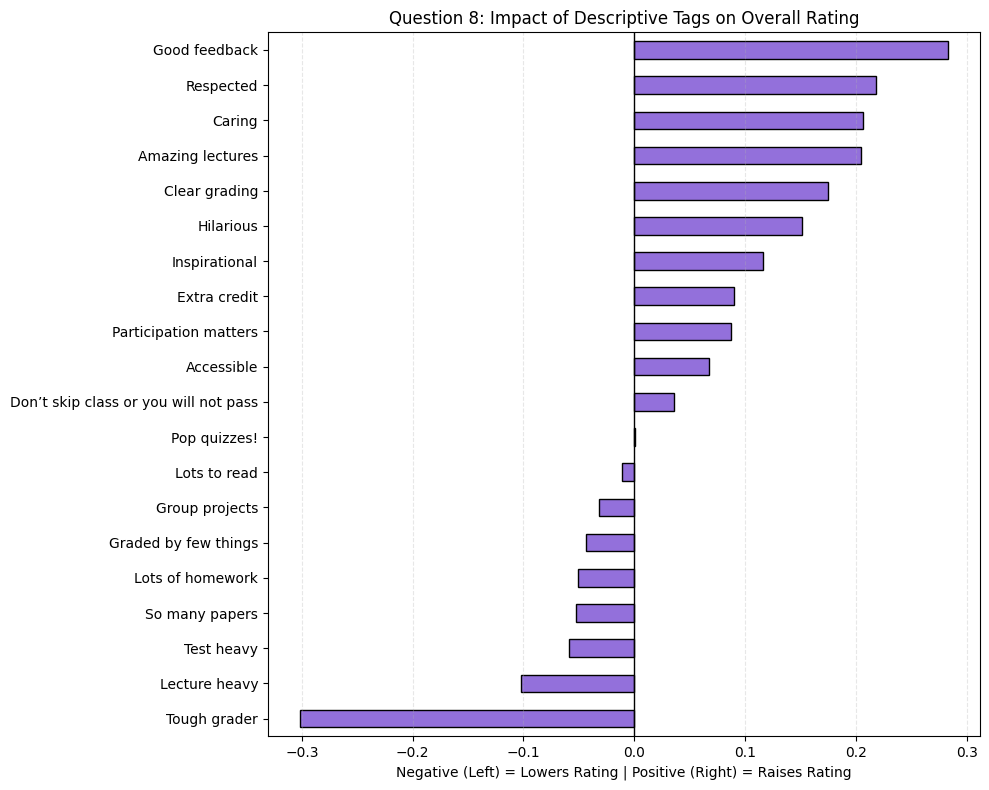

In [34]:
# YOUR EXACT ORDER PROVIDED
tag_names_user = [
    "Tough grader", "Good feedback", "Respected", "Lots to read",
    "Participation matters", "Don’t skip class or you will not pass",
    "Lots of homework", "Inspirational", "Pop quizzes!", "Accessible",
    "So many papers", "Clear grading", "Hilarious", "Test heavy",
    "Graded by few things", "Amazing lectures", "Caring", "Extra credit",
    "Group projects", "Lecture heavy"
]

# --- Q4: GENDER BIAS DIVERGING CHART ---
# Calculate (Male - Female)
df_q4['Diff'] = df_q4['Male_Mean'] - df_q4['Female_Mean']
df_q4['TagName'] = tag_names_user
df_q4_plot = df_q4.sort_values('Diff')

# Colors: Blue for Male-skewed, Pink for Female-skewed
df_q4_plot['Color'] = np.where(df_q4_plot['Diff'] > 0, 'skyblue', 'pink')

plt.figure(figsize=(10, 8))
plt.barh(df_q4_plot['TagName'], df_q4_plot['Diff'], color=df_q4_plot['Color'], edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Question 4: Gender Bias in Tags (Male - Female Frequency)')
plt.xlabel('Pink (Left) = Female Skewed | Blue (Right) = Male Skewed')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Q8: IMPACT ON RATING ---
# Using coefficients from model8
coeffs8_named = pd.Series(model8.coef_, index=tag_names_user).sort_values()

plt.figure(figsize=(10, 8))
coeffs8_named.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Question 8: Impact of Descriptive Tags on Overall Rating')
plt.xlabel('Negative (Left) = Lowers Rating | Positive (Right) = Raises Rating')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

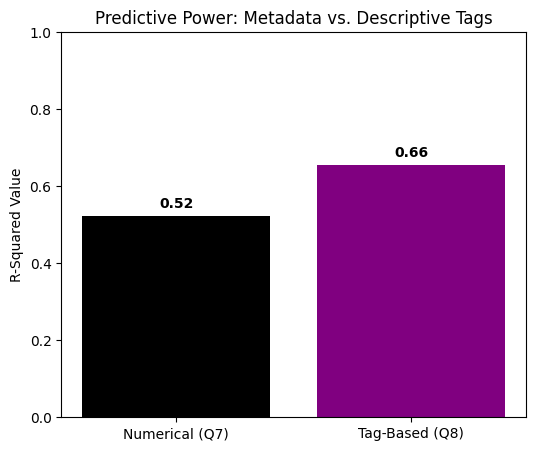

In [20]:
comparison_df = pd.DataFrame({
    'Model': ['Numerical (Q7)', 'Tag-Based (Q8)'],
    'R-Squared': [0.5238, 0.6557] # Use your actual results here
})

plt.figure(figsize=(6, 5))
plt.bar(comparison_df['Model'], comparison_df['R-Squared'], color=['black', 'purple'])
plt.ylim(0, 1)
plt.title('Predictive Power: Metadata vs. Descriptive Tags')
plt.ylabel('R-Squared Value')
for i, val in enumerate(comparison_df['R-Squared']):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')
plt.show()

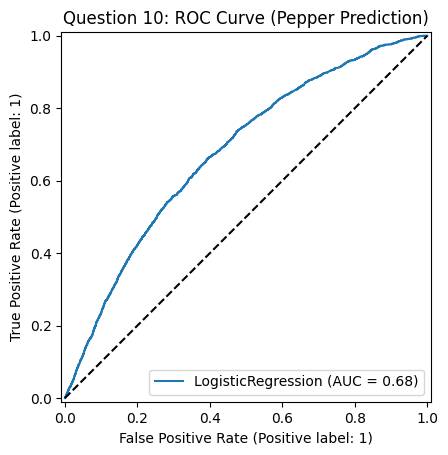

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model10, X_test10, y_test10)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('Question 10: ROC Curve (Pepper Prediction)')
plt.show()

/tmp/ipython-input-4077717768.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




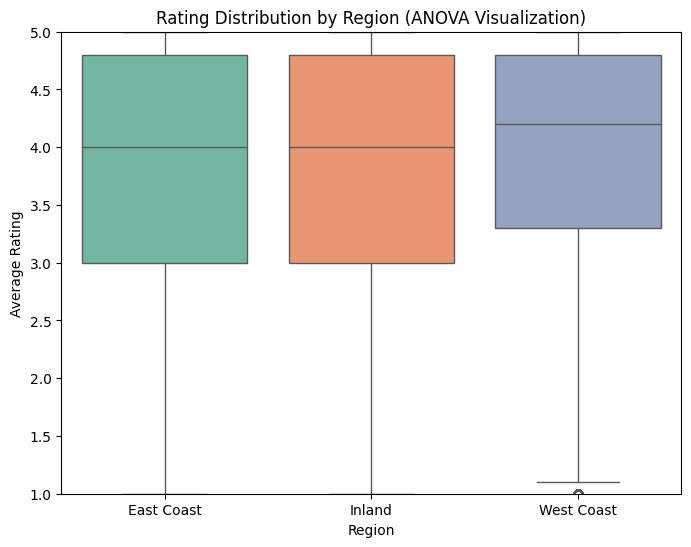

In [22]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Region', y='Rating', data=df_modeling, palette='Set2')
plt.title('Rating Distribution by Region (ANOVA Visualization)')
plt.ylabel('Average Rating')
plt.ylim(1, 5) # Scale to the actual rating range
plt.show()

            Difficulty  NumRatings  TakeAgain    Online    Pepper      Male
Difficulty    1.000000    0.034151  -0.131638 -0.164546  0.028804 -0.017177
NumRatings    0.034151    1.000000   0.202525 -0.092323  0.175626 -0.040479
TakeAgain    -0.131638    0.202525   1.000000  0.155037  0.024263 -0.000649
Online       -0.164546   -0.092323   0.155037  1.000000 -0.050796  0.003725
Pepper        0.028804    0.175626   0.024263 -0.050796  1.000000  0.042049
Male         -0.017177   -0.040479  -0.000649  0.003725  0.042049  1.000000


,feature,VIF
0,Difficulty,7.689789
1,NumRatings,1.540060
2,TakeAgain,1.512864
3,Online,8.911539
4,Pepper,1.127215
5,Male,1.624709


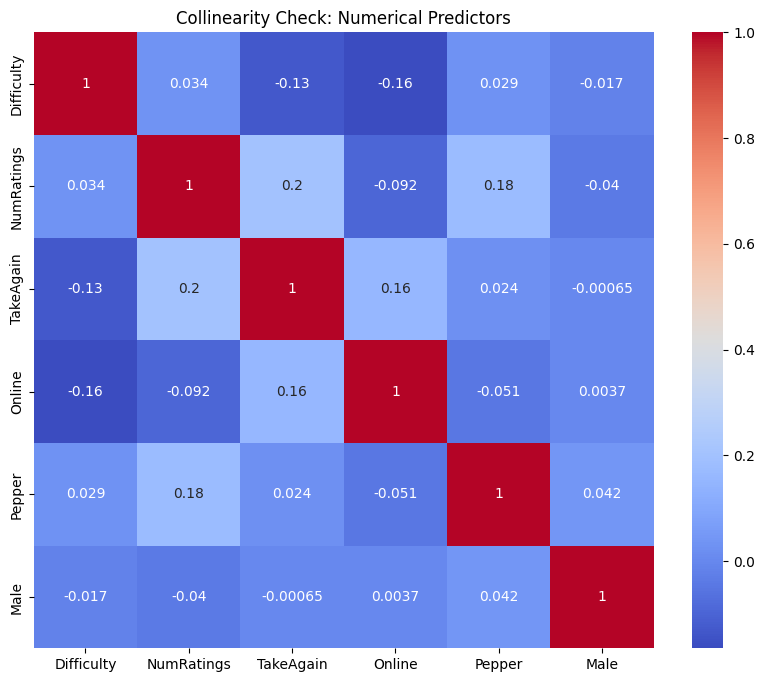

In [23]:


import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_modeling[num_preds].corr(), annot=True, cmap='coolwarm')
plt.title("Collinearity Check: Numerical Predictors")
plt.savefig('q7_correlation.png')
print(df_modeling[num_preds].corr())

# 2. VIF Calculation function
def check_vif(X):
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    v_values = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    vif_df["VIF"] = v_values
    return vif_df
check_vif(df_modeling[num_preds])

In [24]:
# 1. Target is now Column 1 (Difficulty)
y9 = df_modeling.iloc[:, 1]
X9 = df_modeling[tag_cols]
w9 = df_modeling['NumRatings']

# 2. Train/Test Split
X_train9, X_test9, y_train9, y_test9, w_train9, w_test9 = train_test_split(
    X9, y9, w9, test_size=0.2, random_state=RANDOM_SEED
)

# 3. Fit Model
model9 = LinearRegression()
model9.fit(X_train9, y_train9, sample_weight=w_train9)

# 4. Evaluate
y_pred9 = model9.predict(X_test9)
print(f"Q9 R²: {r2_score(y_test9, y_pred9, sample_weight=w_test9):.4f}")
coeffs9 = pd.Series(model9.coef_, index=tag_cols)
print(f"Most Predictive Tag for Difficulty: {coeffs9.abs().idxmax()}")

Q9 R²: 0.4765
Most Predictive Tag for Difficulty: Tag_0


In [25]:
# 1. Apply the filter (e.g., k >= 10)
THRESHOLD = 10
df_filtered = df_modeling[df_modeling['NumRatings'] >= THRESHOLD].copy()

# 2. Run Q7 with Filtered Data
X7_filt = df_filtered[num_preds] # Or your filtered feature list
y7_filt = df_filtered['Rating']
w7_filt = df_filtered['NumRatings']

X_train7, X_test7, y_train7, y_test7, w_train7, w_test7 = train_test_split(
    X7_filt, y7_filt, w7_filt, test_size=0.2, random_state=RANDOM_SEED
)

model7 = LinearRegression()
model7.fit(X_train7, y_train7, sample_weight=w_train7)
print(f"Filtered Q7 R²: {r2_score(y_test7, model7.predict(X_test7), sample_weight=w_test7):.4f}")

# 3. Run Q9 with Filtered Data
X9_filt = df_filtered[tag_cols]
y9_filt = df_filtered['Difficulty']
w9_filt = df_filtered['NumRatings']

X_train9, X_test9, y_train9, y_test9, w_train9, w_test9 = train_test_split(
    X9_filt, y9_filt, w9_filt, test_size=0.2, random_state=RANDOM_SEED
)

model9 = LinearRegression()
model9.fit(X_train9, y_train9, sample_weight=w_train9)
print(f"Filtered Q9 R²: {r2_score(y_test9, model9.predict(X_test9), sample_weight=w_test9):.4f}")

Filtered Q7 R²: 0.7423
Filtered Q9 R²: 0.5917


  Threshold  Count Percentage
0       < 1      0      0.00%
1       < 2  17633     25.19%
2       < 5  44636     63.76%
3      < 10  60163     85.94%
4      < 20  67456     96.36%
5      < 50  69723     99.60%

Percentage below 5 ratings: 63.76%
Percentage below 10 ratings: 85.94%


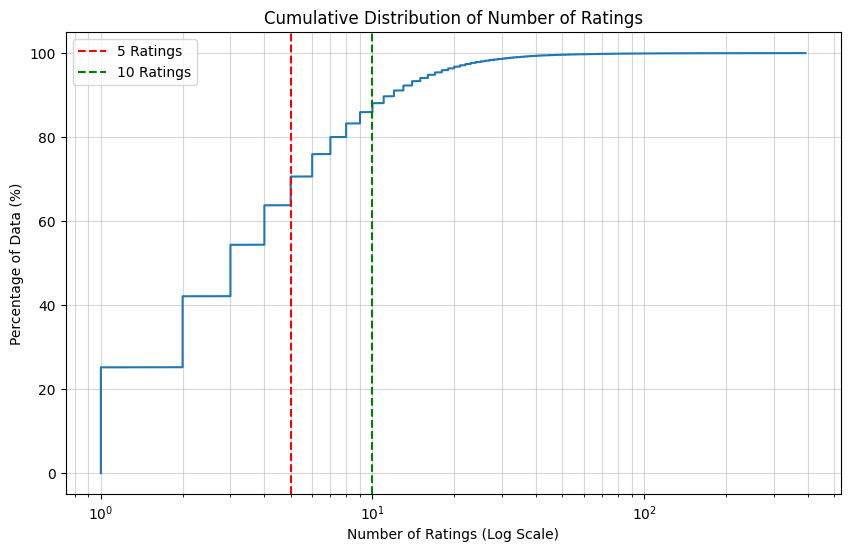

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the numerical data
nums = pd.read_csv('rmpCapstoneNum.csv', header=None)


num_ratings = nums.iloc[:, 2].dropna()

# Calculate percentages for different thresholds
thresholds = [1, 2, 5, 10, 20, 50]
results = []
total = len(num_ratings)

for t in thresholds:
    count = (num_ratings < t).sum()
    percentage = (count / total) * 100
    results.append({'Threshold': f'< {t}', 'Count': count, 'Percentage': f'{percentage:.2f}%'})

results_df = pd.DataFrame(results)
print(results_df)

# Create a cumulative distribution plot
sorted_ratings = sorted(num_ratings)
y = [i / len(sorted_ratings) * 100 for i in range(len(sorted_ratings))]

plt.figure(figsize=(10, 6))
plt.plot(sorted_ratings, y)
plt.xscale('log')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Percentage of Data (%)')
plt.title('Cumulative Distribution of Number of Ratings')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.axvline(x=5, color='r', linestyle='--', label='5 Ratings')
plt.axvline(x=10, color='g', linestyle='--', label='10 Ratings')
plt.legend()
plt.savefig('num_ratings_distribution.png')

# Also check exact percentages for <5 and <10 specifically
p_below_5 = (num_ratings < 5).mean() * 100
p_below_10 = (num_ratings < 10).mean() * 100
print(f"\nPercentage below 5 ratings: {p_below_5:.2f}%")
print(f"Percentage below 10 ratings: {p_below_10:.2f}%")

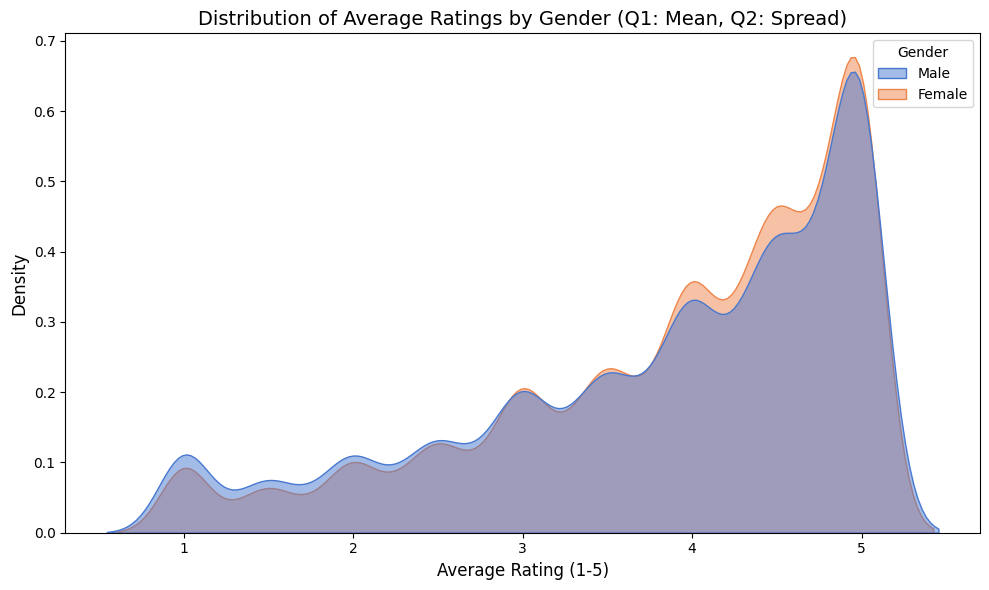

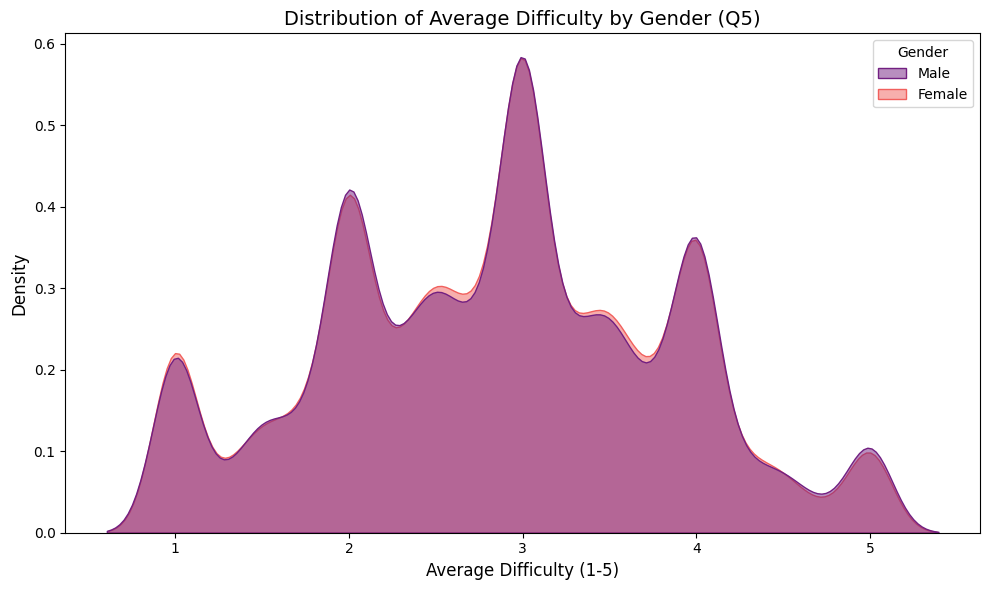

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (ensure files are in the same directory)
nums = pd.read_csv('rmpCapstoneNum.csv', header=None)
nums.columns = ['Rating', 'Difficulty', 'NumRatings', 'TakeAgain', 'Online', 'Pepper', 'Female', 'Male']

# Cleaning to match the 70,004 analytical sample
df = nums.dropna(subset=['Rating']).copy()
df = df[df['NumRatings'] > 0]
df_gender = df[((df['Male'] == 1) & (df['Female'] == 0)) | ((df['Male'] == 0) & (df['Female'] == 1))].copy()
df_gender['Gender'] = np.where(df_gender['Male'] == 1, 'Male', 'Female')

# 1. Visualization for Q1 & Q2: Average Rating Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_gender, x='Rating', hue='Gender', fill=True, common_norm=False, palette='muted', alpha=0.5)
plt.title('Distribution of Average Ratings by Gender (Q1: Mean, Q2: Spread)', fontsize=14)
plt.xlabel('Average Rating (1-5)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.savefig('q1_q2_ratings.png')

# 2. Visualization for Q5: Average Difficulty Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_gender, x='Difficulty', hue='Gender', fill=True, common_norm=False, palette='magma', alpha=0.5)
plt.title('Distribution of Average Difficulty by Gender (Q5)', fontsize=14)
plt.xlabel('Average Difficulty (1-5)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.savefig('q5_difficulty.png')


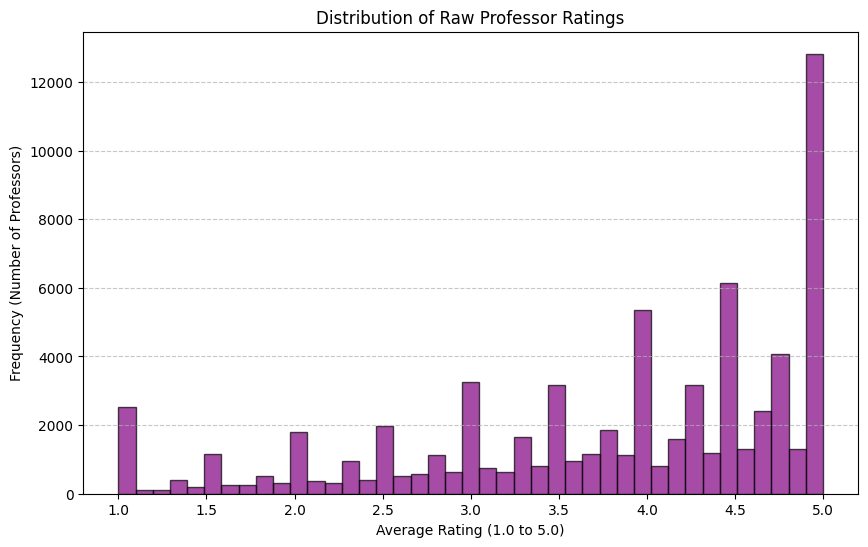

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
nums = pd.read_csv('rmpCapstoneNum.csv', header=None)
nums.columns = ['Rating', 'Difficulty', 'NumRatings', 'TakeAgain', 'Online', 'Pepper', 'Female', 'Male']

# Create a histogram of the 'Rating' column without annotations
plt.figure(figsize=(10, 6))
plt.hist(nums['Rating'].dropna(), bins=41, color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribution of Raw Professor Ratings')
plt.xlabel('Average Rating (1.0 to 5.0)')
plt.ylabel('Frequency (Number of Professors)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the updated image
plt.savefig('raw_ratings_distribution.png')